# Matched10 Alpha Fact Story

This notebook compares the matched10 `alpha=0.05` and `alpha=0.01` ABAPC runs at the fact level and connects those test-set changes to downstream graph quality.

The main questions are:

1. How did the tighter alpha change the initial mix of true and false tests?
2. Did that create more frozen wrong adjacency blocks for `bb-nor`?
3. Where did that mechanism actually matter more than the broader loss of dependency signal?


In [1]:
import os
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
ANALYSIS_DIR = REPO_ROOT / "results" / "analysis"
FIG_DIR = ANALYSIS_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
SAVE_FIGS = False

DATASET_ORDER = ["cancer", "earthquake", "survey", "asia", "sachs", "child"]
METHOD_ORDER = ["ABAPC (nor)", "ABAPC (bb)", "ABAPC (bb-nor)"]
ALPHA_LABELS = {"alpha005": "alpha=0.05", "alpha001": "alpha=0.01"}
ALPHA_COLORS = {"alpha005": "#4C78A8", "alpha001": "#F58518"}

def maybe_save(fig, name: str):
    if SAVE_FIGS:
        fig.savefig(FIG_DIR / name, dpi=180, bbox_inches="tight")

def load_csv(name: str) -> pd.DataFrame:
    path = ANALYSIS_DIR / name
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


In [2]:
initial_means = load_csv("matched10_alpha_fact_compare_initial_means.csv")
initial_seedwise = load_csv("matched10_alpha_fact_compare_initial_seedwise.csv")
method_means = load_csv("matched10_alpha_fact_compare_method_means.csv")
method_seedwise = load_csv("matched10_alpha_fact_compare_method_seedwise.csv")
bb_gap_means = load_csv("matched10_alpha_fact_compare_bb_gap_means.csv")
bb_gap_seedwise = load_csv("matched10_alpha_fact_compare_bb_gap_seedwise.csv")
alpha_delta_means = load_csv("matched10_alpha_fact_compare_alpha_delta_means.csv")
fact_consistency = load_csv("matched10_alpha_fact_compare_fact_consistency_seedwise.csv")

all(
    fact_consistency[col].all()
    for col in fact_consistency.columns
    if col.startswith("facts_match_")
)


True

## Sanity Check

The fact consistency table confirms that, for every dataset/seed/alpha, the three ABAPC variants started from the same fact set. That means any `bb` vs `bb-nor` difference comes from the algorithmic handling of those facts, not from inconsistent inputs.


In [3]:
display(
    fact_consistency.groupby("dataset")[
        [c for c in fact_consistency.columns if c.startswith("facts_match_")]
    ].all()
)


,facts_match_abapc_nor,facts_match_abapc_bb,facts_match_abapc_bb_nor
dataset,,,
asia,True,True,True
cancer,True,True,True
child,True,True,True
earthquake,True,True,True
sachs,True,True,True
survey,True,True,True


## Dataset-Level Story Table

This is the compact table I would use first in a writeup. Negative `d_true_dep` means the tighter alpha removed true dependency facts. Positive `d_false_indep` means it introduced more wrong independence calls. Positive `d_wrong_block` means more true edges got wrongly blocked by at least one independence fact.


In [4]:
init_005 = (
    initial_means[initial_means["alpha"] == "alpha005"]
    .set_index("dataset")
    .loc[DATASET_ORDER]
)
init_001 = (
    initial_means[initial_means["alpha"] == "alpha001"]
    .set_index("dataset")
    .loc[DATASET_ORDER]
)
bb_005 = (
    bb_gap_means[bb_gap_means["alpha"] == "alpha005"]
    .set_index("dataset")
    .loc[DATASET_ORDER]
)
bb_001 = (
    bb_gap_means[bb_gap_means["alpha"] == "alpha001"]
    .set_index("dataset")
    .loc[DATASET_ORDER]
)

story_table = pd.DataFrame({
    "d_total_facts": init_001["facts_total"] - init_005["facts_total"],
    "d_true_dep": init_001["true_dep_count"] - init_005["true_dep_count"],
    "d_false_indep": init_001["false_indep_count"] - init_005["false_indep_count"],
    "d_wrong_block": init_001["wrong_block_pair_count"] - init_005["wrong_block_pair_count"],
    "bb_gap_F1_0.05": bb_005["delta_dag_F1_bb_minus_bb_nor"],
    "bb_gap_F1_0.01": bb_001["delta_dag_F1_bb_minus_bb_nor"],
    "d_bb_gap_F1": bb_001["delta_dag_F1_bb_minus_bb_nor"] - bb_005["delta_dag_F1_bb_minus_bb_nor"],
    "bb_gap_SHD_0.05": bb_005["delta_dag_SHD_bb_minus_bb_nor"],
    "bb_gap_SHD_0.01": bb_001["delta_dag_SHD_bb_minus_bb_nor"],
}).round(3)

display(story_table)


,d_total_facts,d_true_dep,d_false_indep,d_wrong_block,bb_gap_F1_0.05,bb_gap_F1_0.01,d_bb_gap_F1,bb_gap_SHD_0.05,bb_gap_SHD_0.01
dataset,,,,,,,,,
cancer,-6.6,-6.9,1.2,0.3,-0.094,-0.072,0.022,1.0,1.0
earthquake,-2.0,-0.6,0.2,0.0,-0.111,0.000,0.111,0.7,0.0
survey,-13.1,-9.4,-1.2,0.6,-0.110,-0.109,0.001,3.4,2.4
asia,-16.9,-13.9,1.5,0.3,-0.194,-0.155,0.039,11.2,10.8
sachs,-36.6,-30.7,2.7,0.0,-0.173,-0.103,0.070,7.2,5.4
child,-692.6,-616.7,21.4,0.3,-0.708,-0.636,0.072,124.3,117.4


## Plot 1: How The Initial Fact Universe Shifted

This first plot isolates the alpha effect before any ABAPC variant starts removing facts.


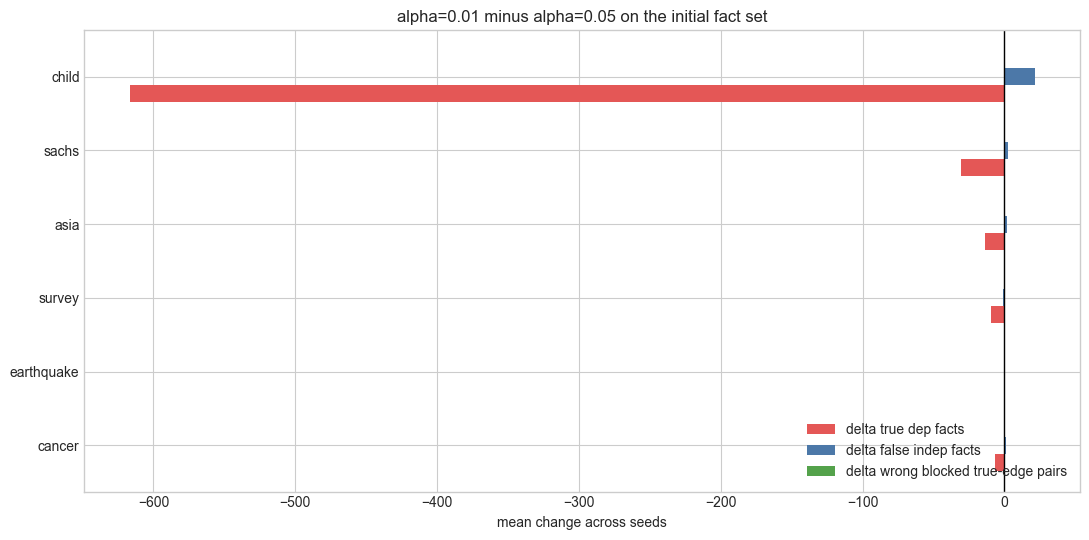

In [5]:
plot_df = story_table.reset_index().rename(columns={"index": "dataset"})
y = np.arange(len(plot_df))
height = 0.23

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.barh(y - height, plot_df["d_true_dep"], height=height, color="#E45756", label="delta true dep facts")
ax.barh(y, plot_df["d_false_indep"], height=height, color="#4C78A8", label="delta false indep facts")
ax.barh(y + height, plot_df["d_wrong_block"], height=height, color="#54A24B", label="delta wrong blocked true-edge pairs")
ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(plot_df["dataset"])
ax.set_title("alpha=0.01 minus alpha=0.05 on the initial fact set")
ax.set_xlabel("mean change across seeds")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
maybe_save(fig, "matched10_alpha_fact_shift.png")
plt.show()


## Table 2: Method-Level Outcome Deltas

The next view compresses the downstream effect into DAG F1 and DAG SHD changes for each method.


In [6]:
method_005 = method_means[method_means["alpha"] == "alpha005"].copy()
method_001 = method_means[method_means["alpha"] == "alpha001"].copy()

method_delta = (
    method_001.set_index(["dataset", "method"])[["dag_F1", "dag_SHD", "elapsed_sec", "removed_true_count", "removed_false_count"]]
    - method_005.set_index(["dataset", "method"])[["dag_F1", "dag_SHD", "elapsed_sec", "removed_true_count", "removed_false_count"]]
).reset_index()

f1_delta_table = (
    method_delta.pivot(index="dataset", columns="method", values="dag_F1")
    .loc[DATASET_ORDER, METHOD_ORDER]
    .round(3)
)
shd_delta_table = (
    method_delta.pivot(index="dataset", columns="method", values="dag_SHD")
    .loc[DATASET_ORDER, METHOD_ORDER]
    .round(1)
)

display(Markdown("**DAG F1 delta: alpha=0.01 minus alpha=0.05**"))
display(f1_delta_table)
display(Markdown("**DAG SHD delta: alpha=0.01 minus alpha=0.05**"))
display(shd_delta_table)


**DAG F1 delta: alpha=0.01 minus alpha=0.05**

method,ABAPC (nor),ABAPC (bb),ABAPC (bb-nor)
dataset,,,
cancer,-0.161,-0.121,-0.143
earthquake,0.022,0.133,0.022
survey,-0.082,0.053,0.052
asia,0.042,-0.065,-0.104
sachs,-0.075,0.008,-0.062
child,-0.060,-0.015,-0.087


**DAG SHD delta: alpha=0.01 minus alpha=0.05**

method,ABAPC (nor),ABAPC (bb),ABAPC (bb-nor)
dataset,,,
cancer,0.7,0.6,0.6
earthquake,-0.2,-0.9,-0.2
survey,0.4,-1.3,-0.3
asia,-0.3,0.2,0.6
sachs,1.2,-0.8,1.0
child,1.8,-4.4,2.5


## Plot 2: Outcome Heatmaps

This makes it easy to see where the alpha change helped or hurt each method.


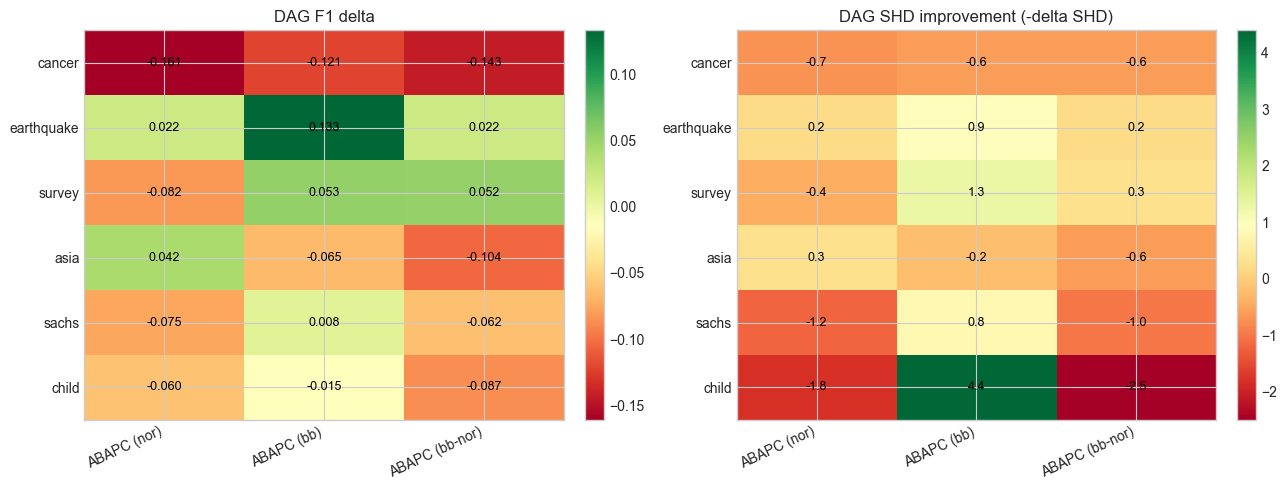

In [7]:
def draw_heatmap(ax, data: pd.DataFrame, title: str, cmap: str, fmt: str):
    values = data.to_numpy()
    im = ax.imshow(values, aspect="auto", cmap=cmap)
    ax.set_xticks(np.arange(data.shape[1]))
    ax.set_xticklabels(data.columns, rotation=25, ha="right")
    ax.set_yticks(np.arange(data.shape[0]))
    ax.set_yticklabels(data.index)
    ax.set_title(title)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            ax.text(j, i, format(values[i, j], fmt), ha="center", va="center", color="black", fontsize=9)
    return im

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
im0 = draw_heatmap(axes[0], f1_delta_table, "DAG F1 delta", "RdYlGn", ".3f")
im1 = draw_heatmap(axes[1], -shd_delta_table, "DAG SHD improvement (-delta SHD)", "RdYlGn", ".1f")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
maybe_save(fig, "matched10_alpha_method_heatmaps.png")
plt.show()


## Plot 3: Did More Wrong Blocks Actually Favor `bb`?

Left: the `bb - bb-nor` DAG F1 gap at each alpha. Closer to zero or positive means `bb` caught up or beat `bb-nor`.

Right: the effective wrong blocked pair gap. Negative values mean `bb-nor` kept more wrong blocked true-edge pairs than `bb`.


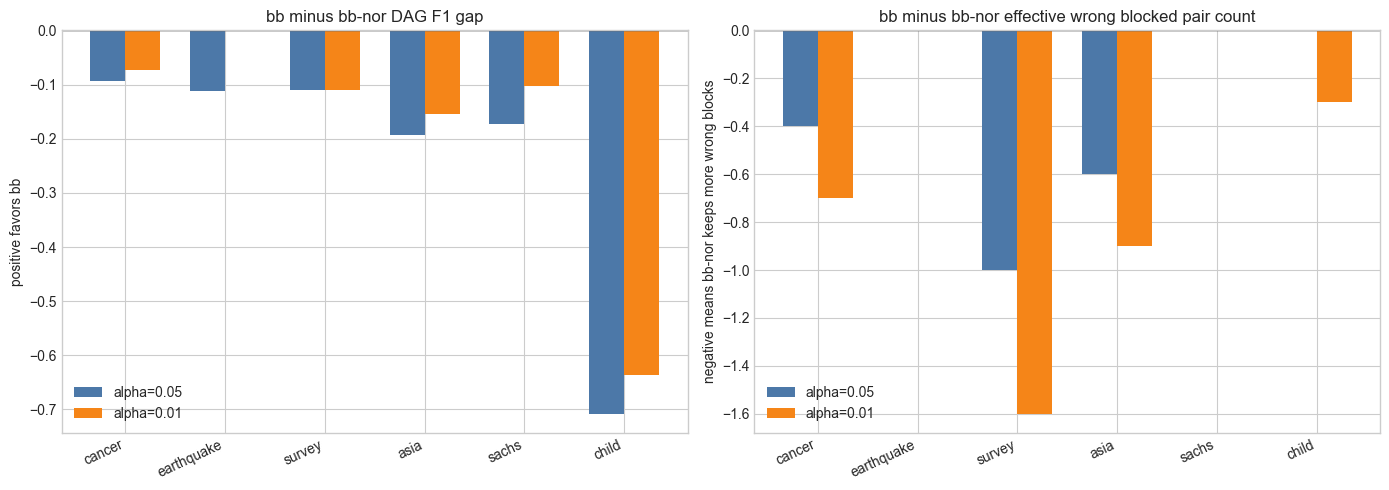

In [8]:
gap_plot = bb_gap_means.copy()
gap_plot["dataset"] = pd.Categorical(gap_plot["dataset"], DATASET_ORDER, ordered=True)
gap_plot = gap_plot.sort_values(["dataset", "alpha"])
x = np.arange(len(DATASET_ORDER))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for offset, alpha in [(-width / 2, "alpha005"), (width / 2, "alpha001")]:
    g = gap_plot[gap_plot["alpha"] == alpha].set_index("dataset").loc[DATASET_ORDER]
    axes[0].bar(
        x + offset,
        g["delta_dag_F1_bb_minus_bb_nor"],
        width=width,
        color=ALPHA_COLORS[alpha],
        label=ALPHA_LABELS[alpha],
    )
    axes[1].bar(
        x + offset,
        g["delta_effective_wrong_block_pair_count_bb_minus_bb_nor"],
        width=width,
        color=ALPHA_COLORS[alpha],
        label=ALPHA_LABELS[alpha],
    )

for ax in axes:
    ax.axhline(0, color="black", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(DATASET_ORDER, rotation=25, ha="right")
    ax.legend(frameon=False)
axes[0].set_title("bb minus bb-nor DAG F1 gap")
axes[0].set_ylabel("positive favors bb")
axes[1].set_title("bb minus bb-nor effective wrong blocked pair count")
axes[1].set_ylabel("negative means bb-nor keeps more wrong blocks")
plt.tight_layout()
maybe_save(fig, "matched10_alpha_bb_gap.png")
plt.show()


## Plot 4: Seed-Level Hypothesis Check

These panels focus on the datasets where wrong blocked true-edge pairs actually occur. If the frozen-block mechanism dominates, higher `wrong_block_pair_count` should push the `bb - bb-nor` F1 gap upward.


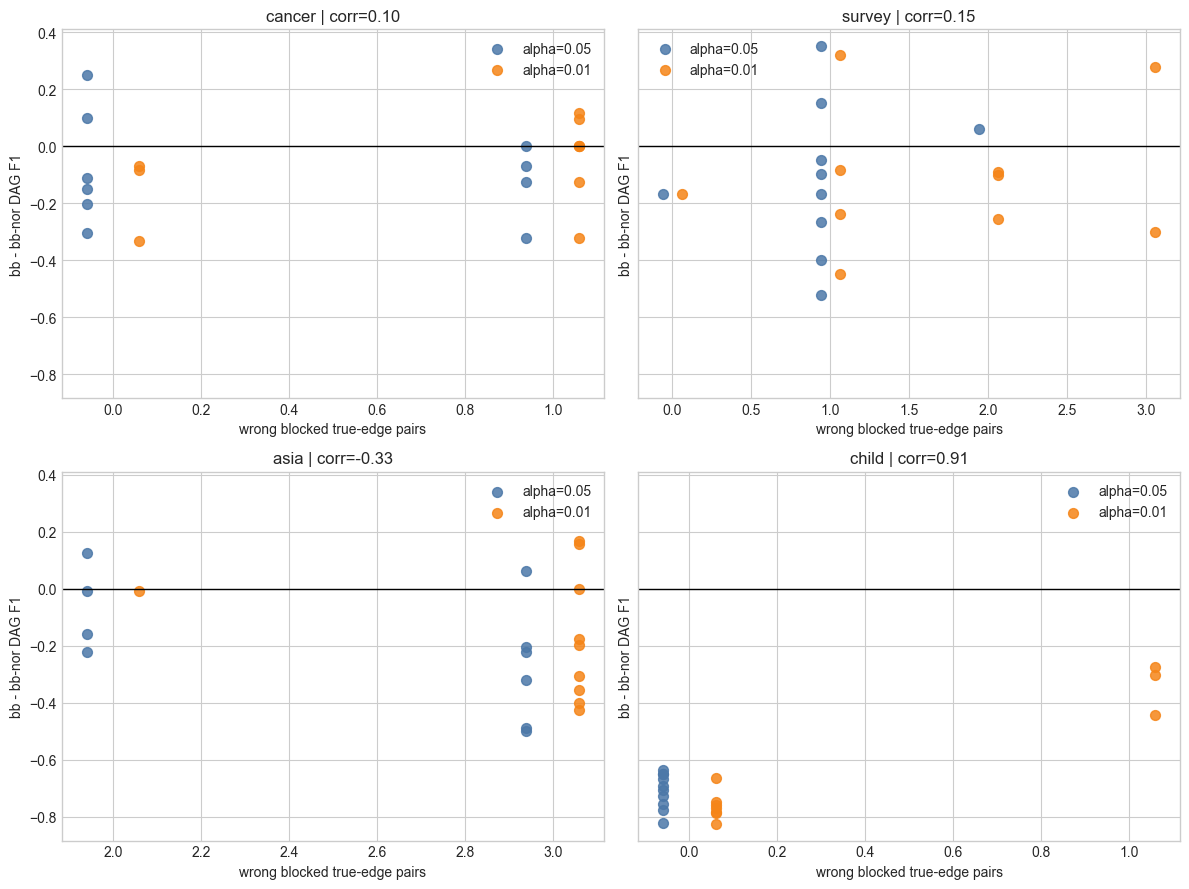

In [9]:
seed_plot = bb_gap_seedwise.merge(
    initial_seedwise[["dataset", "alpha", "seed", "wrong_block_pair_count", "false_indep_count"]],
    on=["dataset", "alpha", "seed"],
    how="left",
)

focus_datasets = ["cancer", "survey", "asia", "child"]
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
axes = axes.flatten()

for ax, dataset in zip(axes, focus_datasets):
    sub = seed_plot[seed_plot["dataset"] == dataset].copy()
    for alpha, dx in [("alpha005", -0.06), ("alpha001", 0.06)]:
        part = sub[sub["alpha"] == alpha]
        ax.scatter(
            part["wrong_block_pair_count"] + dx,
            part["delta_dag_F1_bb_minus_bb_nor"],
            s=50,
            alpha=0.85,
            color=ALPHA_COLORS[alpha],
            label=ALPHA_LABELS[alpha],
        )
    corr = sub["wrong_block_pair_count"].corr(sub["delta_dag_F1_bb_minus_bb_nor"])
    corr_text = "nan" if pd.isna(corr) else f"{corr:.2f}"
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"{dataset} | corr={corr_text}")
    ax.set_xlabel("wrong blocked true-edge pairs")
    ax.set_ylabel("bb - bb-nor DAG F1")
    ax.legend(frameon=False)

plt.tight_layout()
maybe_save(fig, "matched10_alpha_seedwise_wrong_block_vs_gap.png")
plt.show()


## One-Page Takeaway Table

This table turns the numbers into the short narrative I would use in slides or prose.


In [10]:
takeaway = story_table.copy()
takeaway["story"] = np.select(
    [
        (takeaway["d_wrong_block"] > 0) & (takeaway["d_bb_gap_F1"] > 0.02),
        (takeaway["d_wrong_block"] <= 0.05) & (takeaway["d_true_dep"] < -5),
        (takeaway["d_wrong_block"] > 0) & (takeaway["d_bb_gap_F1"] <= 0.02),
    ],
    [
        "Some support for the bb advantage story",
        "Mostly a dependency-signal loss story",
        "Wrong blocks rose, but not enough to flip bb vs bb-nor",
    ],
    default="Largely neutral or denoising",
)
display(
    takeaway[
        ["d_true_dep", "d_false_indep", "d_wrong_block", "d_bb_gap_F1", "story"]
    ].round(3)
)


,d_true_dep,d_false_indep,d_wrong_block,d_bb_gap_F1,story
dataset,,,,,
cancer,-6.9,1.2,0.3,0.022,Some support for the bb advantage story
earthquake,-0.6,0.2,0.0,0.111,Largely neutral or denoising
survey,-9.4,-1.2,0.6,0.001,"Wrong blocks rose, but not enough to flip bb vs bb-nor"
asia,-13.9,1.5,0.3,0.039,Some support for the bb advantage story
sachs,-30.7,2.7,0.0,0.070,Mostly a dependency-signal loss story
child,-616.7,21.4,0.3,0.072,Some support for the bb advantage story


## Notes

- The fact comparison itself comes from [analyze_bnlearn_matched10_alpha_facts.py](/vol/bitbucket/fr920/ArgCausalDisco-1/scripts/analyze_bnlearn_matched10_alpha_facts.py).
- The `bb-nor` mechanism is the frozen initial block-edge behavior in [causalaba_increm.py#L1203](/vol/bitbucket/fr920/ArgCausalDisco-1/causalaba_increm.py#L1203).
- If you want a paper-ready subset, I would keep Plot 1, Plot 3, and the one-page takeaway table.
